# SAR Lab 7: Xinmo Landslide Analysis

This notebook documents the June 24, 2017 Xinmo landslide laboratory
workflow. It combines a pre-event LiCSAR/MintPy SBAS time series with
event-spanning coherence, Sentinel-1 GRD VV change, and Sentinel-2
optical change analysis.

**Current status:** the LiCSAR stack and initial MintPy processing are
complete. Later sections are prepared for the event and Earth Engine
analyses and remain safely executable until their inputs are supplied.

## Reproducibility Header

- **Event:** Xinmo landslide, Sichuan Province, China
- **Event date:** 2017-06-24
- **Approximate landslide location:** 103.6506 E, 32.0661 N
- **Processing AOI:** west 103.62, south 32.04, east 103.68, north 32.09
- **LiCSAR frame:** `062D_05831_131313`
- **MintPy inputs:** `output/mintpy/inputs/`
- **MintPy results:** `output/mintpy/`
- **Reusable figures:** `figures/`

The code below discovers the lab directory automatically, whether the
notebook is launched from `SAR_Lab_7/` or its parent repository.

In [1]:
import os
import platform
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "output" / ".matplotlib"))

import h5py
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import scipy
from matplotlib.patches import Circle
from matplotlib.dates import DateFormatter, YearLocator
from matplotlib.ticker import FormatStrFormatter
from rasterio.windows import from_bounds

EVENT_DATE = pd.Timestamp("2017-06-24")
LANDSLIDE_LON = 103.6506
LANDSLIDE_LAT = 32.0661
AOI = (103.62, 32.04, 103.68, 32.09)
LICSAR_FRAME = "062D_05831_131313"

cwd = Path.cwd().resolve()
if (cwd / "SAR_Lab_7.pdf").exists():
    LAB_DIR = cwd
elif (cwd / "SAR_Lab_7" / "SAR_Lab_7.pdf").exists():
    LAB_DIR = cwd / "SAR_Lab_7"
else:
    raise FileNotFoundError("Run this notebook from SAR_Lab_7/ or its parent repository.")

MINTPY_DIR = LAB_DIR / "output" / "mintpy"
INPUTS_DIR = MINTPY_DIR / "inputs"
FIGURES_DIR = LAB_DIR / "figures"
EE_OUTPUT_DIR = LAB_DIR / "output" / "earth_engine"
EVENT_COH_DIR = LAB_DIR / "data" / "event_coherence"
EVENT_COH_OUTPUT_DIR = LAB_DIR / "output" / "event_coherence"

for directory in (
    FIGURES_DIR,
    EE_OUTPUT_DIR,
    EVENT_COH_DIR,
    EVENT_COH_OUTPUT_DIR,
    Path(os.environ["MPLCONFIGDIR"]),
):
    directory.mkdir(parents=True, exist_ok=True)

required_files = [
    INPUTS_DIR / "ifgramStack.h5",
    INPUTS_DIR / "geometryGeo.h5",
    MINTPY_DIR / "timeseries.h5",
    MINTPY_DIR / "velocity.h5",
    MINTPY_DIR / "temporalCoherence.h5",
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required MintPy files:\n" + "\n".join(missing))

versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "Platform": platform.platform(),
        "NumPy": np.__version__,
        "Pandas": pd.__version__,
        "SciPy": scipy.__version__,
        "Matplotlib": matplotlib.__version__,
        "h5py": h5py.__version__,
        "Rasterio": rasterio.__version__,
    },
    name="Version",
)
versions.to_frame()

,Version
Python,3.11.15
Platform,macOS-26.1-arm64-arm-64bit
NumPy,2.4.6
Pandas,3.0.3
SciPy,1.17.1
Matplotlib,3.10.9
h5py,3.16.0
Rasterio,1.4.4


## 1. Study Area and Assignment Objectives

The assignment has three linked objectives:

1. Reconstruct pre-failure deformation with an SBAS time series.
2. Compare event mapping using LiCSAR coherence loss and Sentinel-1 VV
   backscatter change.
3. Map the affected area with Sentinel-2 and quantify land-surface
   change using indices such as NDVI and BSI.

The plots below verify the MintPy subset and place the approximate
landslide location inside the processed terrain.

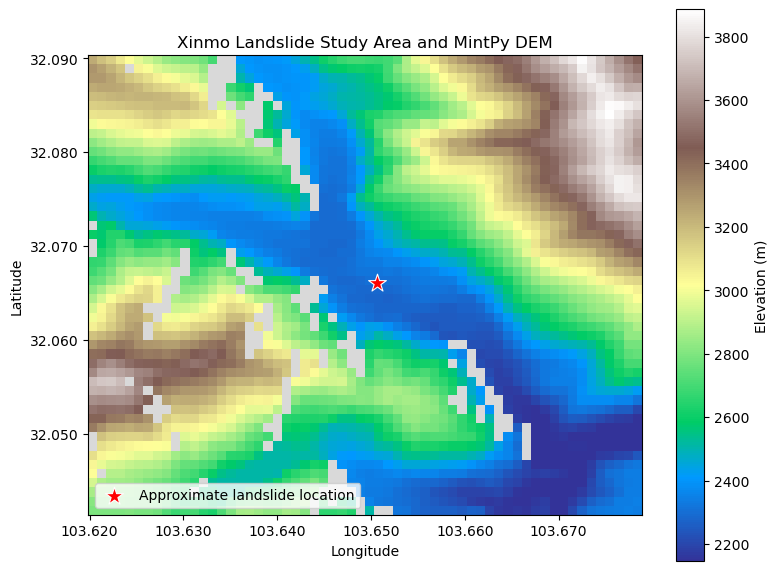

Nearest MintPy pixel to the landslide: Y/X = (24, 31)
Saved: figures/study_area_dem.png


In [2]:
def read_attrs(h5_file):
    return {key: value.decode() if isinstance(value, bytes) else value
            for key, value in h5_file.attrs.items()}


def pixel_centers(attrs, shape):
    rows, cols = shape
    x_first = float(attrs["X_FIRST"])
    y_first = float(attrs["Y_FIRST"])
    x_step = float(attrs["X_STEP"])
    y_step = float(attrs["Y_STEP"])
    lon = x_first + x_step * (np.arange(cols) + 0.5)
    lat = y_first + y_step * (np.arange(rows) + 0.5)
    return lon, lat


def nearest_pixel(lon, lat, target_lon, target_lat):
    x = int(np.argmin(np.abs(lon - target_lon)))
    y = int(np.argmin(np.abs(lat - target_lat)))
    return y, x


with h5py.File(INPUTS_DIR / "geometryGeo.h5", "r") as h5:
    geometry_attrs = read_attrs(h5)
    height = h5["height"][:]
    longitude = h5["longitude"][:]
    latitude = h5["latitude"][:]

lon_axis = longitude[0, :]
lat_axis = latitude[:, 0]
landslide_yx = nearest_pixel(
    lon_axis, lat_axis, LANDSLIDE_LON, LANDSLIDE_LAT
)

dem_data = np.ma.masked_where(height == 0, height)
dem_cmap = plt.get_cmap("terrain").copy()
dem_cmap.set_bad("#d9d9d9")

fig, ax = plt.subplots(figsize=(8, 6))
dem = ax.imshow(
    dem_data,
    extent=[lon_axis.min(), lon_axis.max(), lat_axis.min(), lat_axis.max()],
    origin="upper",
    cmap=dem_cmap,
)
ax.scatter(
    LANDSLIDE_LON,
    LANDSLIDE_LAT,
    marker="*",
    s=180,
    color="red",
    edgecolor="white",
    linewidth=0.8,
    label="Approximate landslide location",
)
ax.set(
    title="Xinmo Landslide Study Area and MintPy DEM",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.legend(loc="lower left")
fig.colorbar(dem, ax=ax, label="Elevation (m)")
fig.tight_layout()
study_area_figure = FIGURES_DIR / "study_area_dem.png"
fig.savefig(study_area_figure, dpi=220, bbox_inches="tight")
plt.show()

print(f"Nearest MintPy pixel to the landslide: Y/X = {landslide_yx}")
print(f"Saved: {study_area_figure.relative_to(LAB_DIR)}")

## 2. LiCSAR Network and MintPy Processing

LiCSAR frame `062D_05831_131313` was filtered to interferograms ending
before the event. A 108-day maximum temporal baseline was used because
the original 72-day selection produced two disconnected network
components. The expanded selection contains a bridging interferogram
and can be inverted as one connected network.

,Value
Acquisition start,2014-10-09
Acquisition end,2017-06-07
Number of acquisitions,42
Number of interferograms,127
Maximum temporal baseline (days),108
Perpendicular baseline min (m),-178.0
Perpendicular baseline max (m),189.0


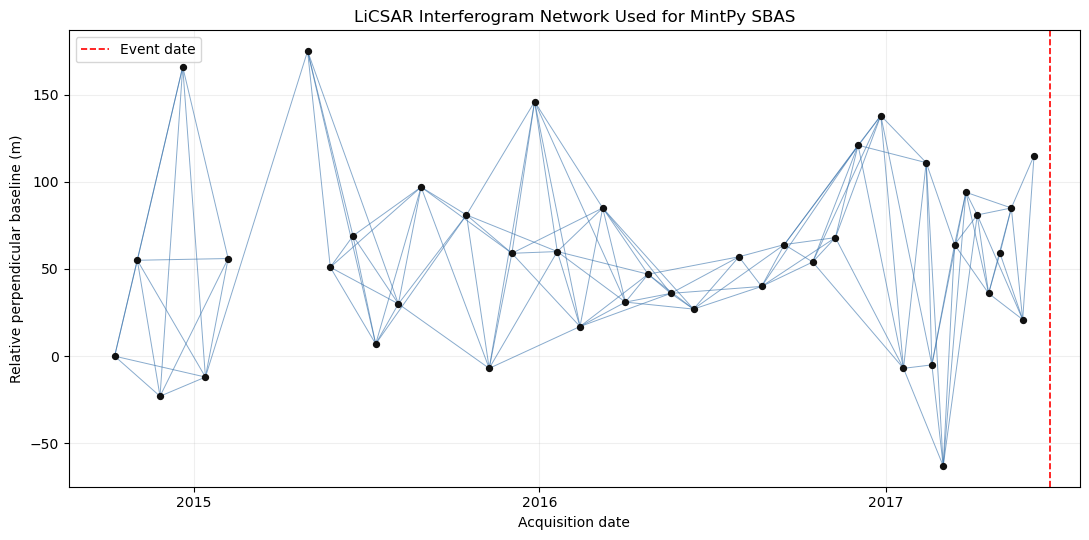

Saved: figures/mintpy_network_overview.png


In [3]:
with h5py.File(INPUTS_DIR / "ifgramStack.h5", "r") as h5:
    stack_attrs = read_attrs(h5)
    date_pairs = h5["date"][:].astype(str)
    pair_bperp = h5["bperp"][:].astype(float)
    drop_ifgram = h5["dropIfgram"][:].astype(bool)

pair_table = pd.DataFrame(date_pairs, columns=["reference_date", "secondary_date"])
pair_table["reference_date"] = pd.to_datetime(pair_table["reference_date"])
pair_table["secondary_date"] = pd.to_datetime(pair_table["secondary_date"])
pair_table["temporal_baseline_days"] = (
    pair_table["secondary_date"] - pair_table["reference_date"]
).dt.days
pair_table["perpendicular_baseline_m"] = pair_bperp
pair_table["kept"] = drop_ifgram

acquisitions = pd.DatetimeIndex(
    sorted(set(pair_table["reference_date"]) | set(pair_table["secondary_date"]))
)
baseline_by_date = {}
for row in pair_table.itertuples():
    baseline_by_date.setdefault(row.reference_date, 0.0)
    baseline_by_date.setdefault(
        row.secondary_date,
        baseline_by_date[row.reference_date] + row.perpendicular_baseline_m,
    )

network_summary = pd.Series(
    {
        "Acquisition start": acquisitions.min().date(),
        "Acquisition end": acquisitions.max().date(),
        "Number of acquisitions": len(acquisitions),
        "Number of interferograms": len(pair_table),
        "Maximum temporal baseline (days)": int(
            pair_table["temporal_baseline_days"].max()
        ),
        "Perpendicular baseline min (m)": float(pair_bperp.min()),
        "Perpendicular baseline max (m)": float(pair_bperp.max()),
    },
    name="Value",
)
display(network_summary.to_frame())

fig, ax = plt.subplots(figsize=(11, 5.5))
for row in pair_table.itertuples():
    color = "#3973ac" if row.kept else "#b0b0b0"
    ax.plot(
        [row.reference_date, row.secondary_date],
        [
            baseline_by_date.get(row.reference_date, 0.0),
            baseline_by_date.get(row.secondary_date, row.perpendicular_baseline_m),
        ],
        color=color,
        linewidth=0.7,
        alpha=0.6,
    )
ax.scatter(
    acquisitions,
    [baseline_by_date.get(date, 0.0) for date in acquisitions],
    color="#111111",
    s=18,
    zorder=3,
)
ax.axvline(EVENT_DATE, color="red", linestyle="--", linewidth=1.2, label="Event date")
ax.set(
    title="LiCSAR Interferogram Network Used for MintPy SBAS",
    xlabel="Acquisition date",
    ylabel="Relative perpendicular baseline (m)",
)
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
network_figure = FIGURES_DIR / "mintpy_network_overview.png"
fig.savefig(network_figure, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {network_figure.relative_to(LAB_DIR)}")

## 3. Reference-Point Selection and SBAS Result

MintPy was first run with an automatic reference point. A nearby stable
pixel outside the landslide was then selected manually and the workflow
rerun from `reference_point`. The current HDF5 metadata records the
final reference at Y/X `19/26`.

Velocity is shown in millimeters per year for readability. The
time-series plot compares the approximate landslide pixel with the
final reference pixel.

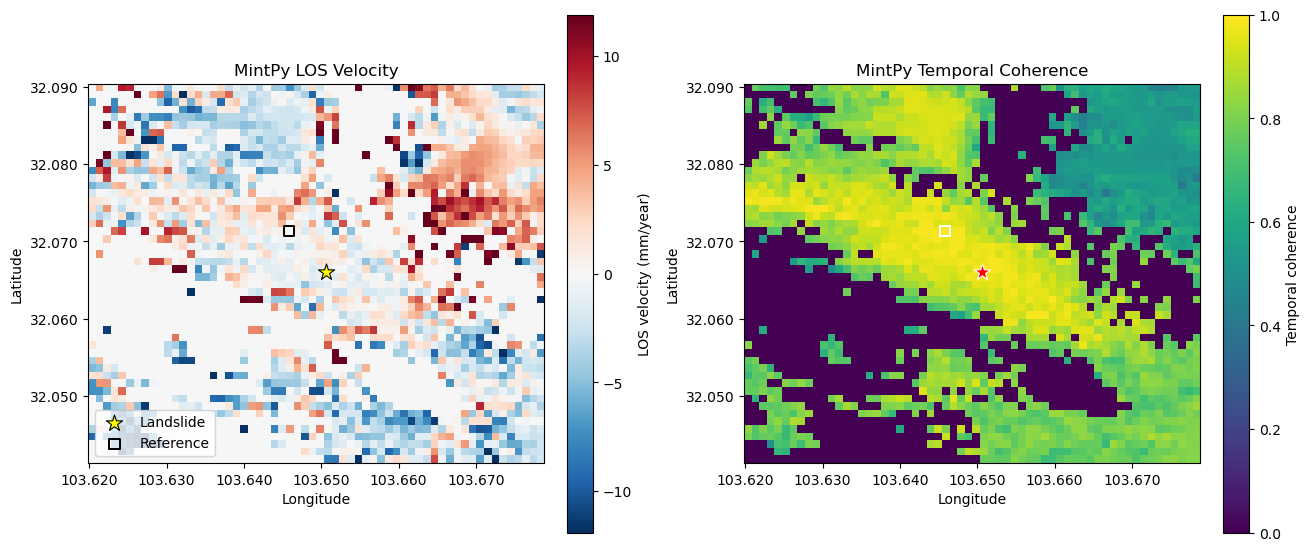

,Value
Reference Y,19.000000
Reference X,26.000000
Reference latitude,32.071334
Reference longitude,103.645832
Landslide Y,24.000000
Landslide X,31.000000
Landslide velocity (mm/year),-1.055130
Landslide temporal coherence,0.988331


Saved: figures/mintpy_velocity_temporal_coherence.png


In [4]:
with h5py.File(MINTPY_DIR / "velocity.h5", "r") as h5:
    velocity_attrs = read_attrs(h5)
    velocity = h5["velocity"][:]
    velocity_std = h5["velocityStd"][:]

with h5py.File(MINTPY_DIR / "temporalCoherence.h5", "r") as h5:
    temporal_coherence = h5["temporalCoherence"][:]

ref_y = int(velocity_attrs["REF_Y"])
ref_x = int(velocity_attrs["REF_X"])
ref_lon = float(velocity_attrs["REF_LON"])
ref_lat = float(velocity_attrs["REF_LAT"])

velocity_mm = velocity * 1000.0
valid_velocity = velocity_mm[np.isfinite(velocity_mm)]
vmax = max(5.0, float(np.nanpercentile(np.abs(valid_velocity), 98)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), constrained_layout=True)
extent = [lon_axis.min(), lon_axis.max(), lat_axis.min(), lat_axis.max()]

im0 = axes[0].imshow(
    velocity_mm,
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].scatter(
    LANDSLIDE_LON, LANDSLIDE_LAT, marker="*", s=150,
    color="yellow", edgecolor="black", linewidth=0.8, label="Landslide"
)
axes[0].scatter(
    ref_lon, ref_lat, marker="s", s=55,
    facecolor="none", edgecolor="black", linewidth=1.4, label="Reference"
)
axes[0].set(title="MintPy LOS Velocity", xlabel="Longitude", ylabel="Latitude")
axes[0].xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[0].legend(loc="lower left")
fig.colorbar(im0, ax=axes[0], label="LOS velocity (mm/year)")

im1 = axes[1].imshow(
    temporal_coherence,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[1].scatter(
    LANDSLIDE_LON, LANDSLIDE_LAT, marker="*", s=150,
    color="red", edgecolor="white", linewidth=0.8
)
axes[1].scatter(
    ref_lon, ref_lat, marker="s", s=55,
    facecolor="none", edgecolor="white", linewidth=1.4
)
axes[1].set(
    title="MintPy Temporal Coherence",
    xlabel="Longitude",
    ylabel="Latitude",
)
axes[1].xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
fig.colorbar(im1, ax=axes[1], label="Temporal coherence")

result_map_figure = FIGURES_DIR / "mintpy_velocity_temporal_coherence.png"
fig.savefig(result_map_figure, dpi=220, bbox_inches="tight")
plt.show()

reference_summary = pd.Series(
    {
        "Reference Y": ref_y,
        "Reference X": ref_x,
        "Reference latitude": ref_lat,
        "Reference longitude": ref_lon,
        "Landslide Y": landslide_yx[0],
        "Landslide X": landslide_yx[1],
        "Landslide velocity (mm/year)": velocity_mm[landslide_yx],
        "Landslide temporal coherence": temporal_coherence[landslide_yx],
    },
    name="Value",
)
display(reference_summary.to_frame())
print(f"Saved: {result_map_figure.relative_to(LAB_DIR)}")

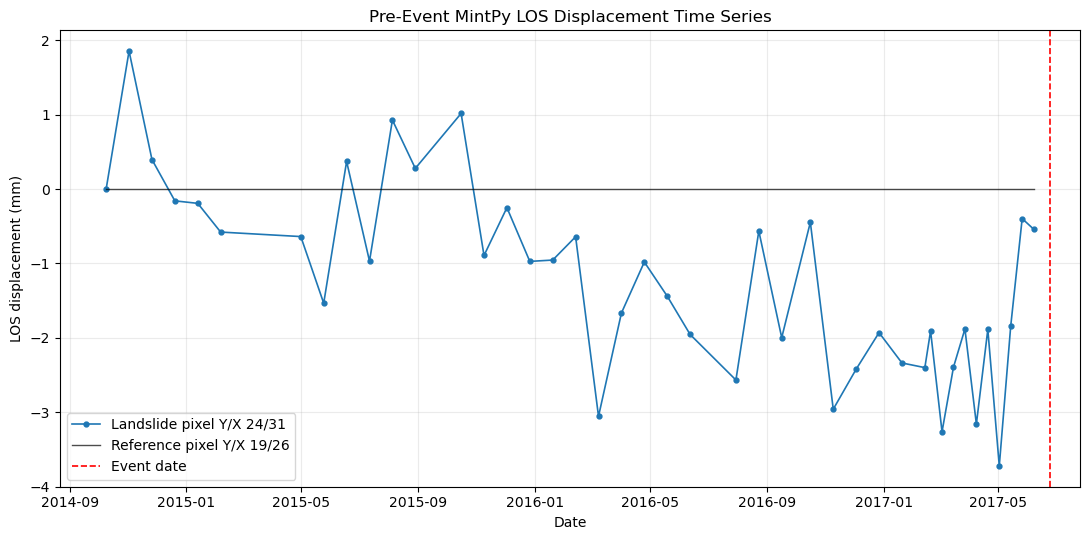

,landslide_displacement_mm,reference_displacement_mm
date,,
2017-02-19,-1.91,-0.0
2017-03-03,-3.26,-0.0
2017-03-15,-2.40,-0.0
2017-03-27,-1.88,-0.0
2017-04-08,-3.16,-0.0
2017-04-20,-1.89,-0.0
2017-05-02,-3.72,-0.0
2017-05-14,-1.84,-0.0
2017-05-26,-0.40,-0.0


Saved: figures/mintpy_landslide_timeseries.png
The final LiCSAR acquisition is 2017-06-07 which precedes the June 24 event and omits the final observations shown in the paper.


In [5]:
with h5py.File(MINTPY_DIR / "timeseries.h5", "r") as h5:
    timeseries_attrs = read_attrs(h5)
    dates = pd.to_datetime(h5["date"][:].astype(str))
    displacement = h5["timeseries"][:]

landslide_series_mm = displacement[:, landslide_yx[0], landslide_yx[1]] * 1000.0
reference_series_mm = displacement[:, ref_y, ref_x] * 1000.0

time_series_table = pd.DataFrame(
    {
        "date": dates,
        "landslide_displacement_mm": landslide_series_mm,
        "reference_displacement_mm": reference_series_mm,
    }
).set_index("date")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(
    time_series_table.index,
    time_series_table["landslide_displacement_mm"],
    marker="o",
    markersize=3.5,
    linewidth=1.2,
    label=f"Landslide pixel Y/X {landslide_yx[0]}/{landslide_yx[1]}",
)
ax.plot(
    time_series_table.index,
    time_series_table["reference_displacement_mm"],
    color="black",
    linewidth=1.0,
    alpha=0.7,
    label=f"Reference pixel Y/X {ref_y}/{ref_x}",
)
ax.axvline(EVENT_DATE, color="red", linestyle="--", linewidth=1.2, label="Event date")
ax.set(
    title="Pre-Event MintPy LOS Displacement Time Series",
    xlabel="Date",
    ylabel="LOS displacement (mm)",
)
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
time_series_figure = FIGURES_DIR / "mintpy_landslide_timeseries.png"
fig.savefig(time_series_figure, dpi=220, bbox_inches="tight")
plt.show()

display(time_series_table.tail(10).round(2))
print(f"Saved: {time_series_figure.relative_to(LAB_DIR)}")
print(
    "The final LiCSAR acquisition is",
    dates.max().date(),
    "which precedes the June 24 event and omits the final observations shown in the paper.",
)

### Initial SBAS Interpretation

Complete this narrative after reviewing the velocity map and several
nearby pixels in `tsview.py`:

- Describe the sign and magnitude of deformation at the landslide.
- State whether the series appears linear, seasonal, accelerating, or
  noisy.
- Explain why the manual reference pixel improves interpretation.
- Compare the timing qualitatively with the PS-based result in the
  supplied paper.
- Note that the LiCSAR stack ends on June 7, 2017, so it cannot reproduce
  every late pre-failure point shown in the paper.

## 4. Event-Spanning Coherence

The selected LiCSAR pair is `20170607_20170725`, with acquisitions 17
days before and 31 days after the event. Its 48-day temporal baseline is
the shortest available pair spanning June 24, 2017.

LiCSAR stores this coherence raster as unsigned bytes. Valid values are
normalized by 255 to the conventional `0-1` coherence range. The
comparison below uses equal-radius samples centered on:

- the approximate landslide location; and
- the manually selected stable MintPy reference point.

These samples are transparent local proxies, not a final mapped
landslide polygon.

In [6]:
EVENT_PAIR = "20170607_20170725"
EVENT_COH_FILE = EVENT_COH_DIR / f"{EVENT_PAIR}.geo.cc.tif"
EVENT_COH_CROP = EVENT_COH_OUTPUT_DIR / f"{EVENT_PAIR}_aoi.geo.cc.tif"
EVENT_COH_STATS = EVENT_COH_OUTPUT_DIR / f"{EVENT_PAIR}_coherence_stats.csv"
SAMPLE_RADIUS_DEG = 0.0025

if not EVENT_COH_FILE.exists():
    raise FileNotFoundError(
        f"Missing {EVENT_COH_FILE.relative_to(LAB_DIR)}. "
        "Download the selected event-spanning coherence raster first."
    )

with rasterio.open(EVENT_COH_FILE) as src:
    crop_window = from_bounds(*AOI, transform=src.transform)
    crop_window = crop_window.round_offsets().round_lengths()
    coherence_raw = src.read(1, window=crop_window).astype(np.float32)
    coherence_transform = src.window_transform(crop_window)
    coherence_profile = src.profile.copy()
    coherence_profile.update(
        height=coherence_raw.shape[0],
        width=coherence_raw.shape[1],
        transform=coherence_transform,
        dtype="float32",
        nodata=np.nan,
        compress="deflate",
    )

coherence = coherence_raw / 255.0
coherence[coherence_raw == 0] = np.nan

with rasterio.open(EVENT_COH_CROP, "w", **coherence_profile) as dst:
    dst.write(coherence.astype(np.float32), 1)

coh_rows, coh_cols = np.indices(coherence.shape)
coh_lon = coherence_transform.c + coherence_transform.a * (coh_cols + 0.5)
coh_lat = coherence_transform.f + coherence_transform.e * (coh_rows + 0.5)

sample_centers = {
    "Landslide-centered sample": (LANDSLIDE_LON, LANDSLIDE_LAT),
    "Stable reference sample": (ref_lon, ref_lat),
}
sample_values = {}
stats_rows = []

for sample_name, (sample_lon, sample_lat) in sample_centers.items():
    sample_mask = (
        (coh_lon - sample_lon) ** 2 + (coh_lat - sample_lat) ** 2
        <= SAMPLE_RADIUS_DEG**2
    )
    values = coherence[sample_mask & np.isfinite(coherence)]
    sample_values[sample_name] = values
    stats_rows.append(
        {
            "sample": sample_name,
            "center_lon": sample_lon,
            "center_lat": sample_lat,
            "radius_degrees": SAMPLE_RADIUS_DEG,
            "valid_pixels": values.size,
            "mean_coherence": values.mean(),
            "median_coherence": np.median(values),
            "std_coherence": values.std(),
            "q25": np.percentile(values, 25),
            "q75": np.percentile(values, 75),
            "fraction_below_0_15": np.mean(values < 0.15),
        }
    )

coherence_stats = pd.DataFrame(stats_rows).set_index("sample")
coherence_stats.to_csv(EVENT_COH_STATS)

landslide_mean = coherence_stats.loc[
    "Landslide-centered sample", "mean_coherence"
]
stable_mean = coherence_stats.loc[
    "Stable reference sample", "mean_coherence"
]
mean_ratio = landslide_mean / stable_mean

display(coherence_stats.round(3))
print(f"Landslide/stable mean coherence ratio: {mean_ratio:.2f}")
print(f"Saved crop: {EVENT_COH_CROP.relative_to(LAB_DIR)}")
print(f"Saved statistics: {EVENT_COH_STATS.relative_to(LAB_DIR)}")

,center_lon,center_lat,radius_degrees,valid_pixels,mean_coherence,median_coherence,std_coherence,q25,q75,fraction_below_0_15
sample,,,,,,,,,,
Landslide-centered sample,103.651,32.066,0.002,20,0.046,0.037,0.023,0.030,0.063,1.000
Stable reference sample,103.646,32.071,0.002,21,0.198,0.184,0.104,0.098,0.306,0.333


Landslide/stable mean coherence ratio: 0.23
Saved crop: output/event_coherence/20170607_20170725_aoi.geo.cc.tif
Saved statistics: output/event_coherence/20170607_20170725_coherence_stats.csv


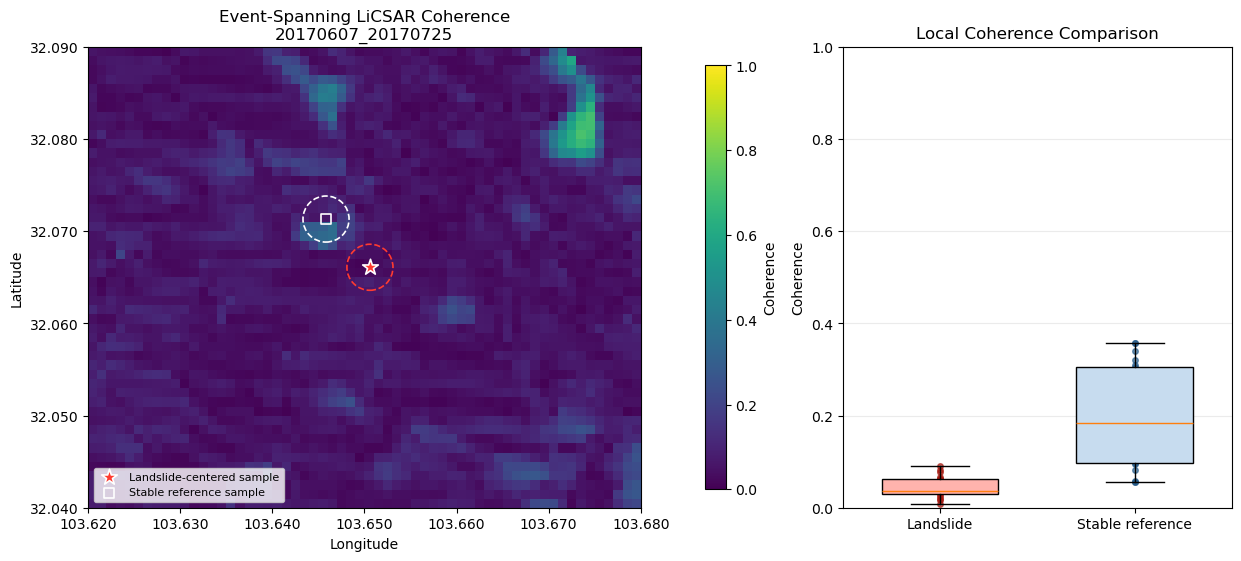

Saved: figures/event_spanning_coherence.png


In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [1.35, 0.75]},
    constrained_layout=True,
)

coherence_map = axes[0].imshow(
    coherence,
    extent=[AOI[0], AOI[2], AOI[1], AOI[3]],
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
colors = {
    "Landslide-centered sample": "#ff3b30",
    "Stable reference sample": "#ffffff",
}
for sample_name, (sample_lon, sample_lat) in sample_centers.items():
    axes[0].scatter(
        sample_lon,
        sample_lat,
        marker="*" if "Landslide" in sample_name else "s",
        s=140 if "Landslide" in sample_name else 55,
        facecolor=colors[sample_name] if "Landslide" in sample_name else "none",
        edgecolor="white",
        linewidth=1.2,
        label=sample_name,
        zorder=4,
    )
    axes[0].add_patch(
        Circle(
            (sample_lon, sample_lat),
            SAMPLE_RADIUS_DEG,
            fill=False,
            edgecolor=colors[sample_name],
            linewidth=1.2,
            linestyle="--",
        )
    )

axes[0].set(
    title=f"Event-Spanning LiCSAR Coherence\n{EVENT_PAIR}",
    xlabel="Longitude",
    ylabel="Latitude",
)
axes[0].xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
axes[0].legend(loc="lower left", fontsize=8)
fig.colorbar(coherence_map, ax=axes[0], label="Coherence", shrink=0.92)

box_data = [
    sample_values["Landslide-centered sample"],
    sample_values["Stable reference sample"],
]
box = axes[1].boxplot(
    box_data,
    tick_labels=["Landslide", "Stable reference"],
    patch_artist=True,
    widths=0.6,
)
box["boxes"][0].set(facecolor="#ffb3ad")
box["boxes"][1].set(facecolor="#c7dcef")
axes[1].scatter(
    np.repeat(1, box_data[0].size),
    box_data[0],
    color="#a71910",
    s=16,
    alpha=0.65,
)
axes[1].scatter(
    np.repeat(2, box_data[1].size),
    box_data[1],
    color="#245b8a",
    s=16,
    alpha=0.65,
)
axes[1].set(
    title="Local Coherence Comparison",
    ylabel="Coherence",
    ylim=(0, 1),
)
axes[1].grid(axis="y", alpha=0.25)

coherence_figure = FIGURES_DIR / "event_spanning_coherence.png"
fig.savefig(coherence_figure, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {coherence_figure.relative_to(LAB_DIR)}")

### Coherence Interpretation

The event-spanning pair shows substantially lower coherence in the
landslide-centered sample than around the stable reference pixel. For
the equal-radius samples used here, mean coherence is approximately
`0.046` at the landslide and `0.198` at the stable reference, so the
landslide sample retains only about 23% of the stable sample's mean
coherence.

This indicates that coherence loss is useful as supporting evidence for
the disturbed area in this case. It is not sufficient as a standalone
landslide map because coherence is low across much of the mountainous
AOI. The 48-day interval also includes temporal decorrelation unrelated
to the failure, while vegetation, moisture change, steep-terrain
layover/shadow, and geometric differences can all reduce coherence.
The point-centered sample is also only a proxy until the optical
analysis provides a mapped landslide polygon.

## 5. Sentinel-1 VV Change

This section will compare consistent descending-orbit Sentinel-1 GRD
acquisitions before and after the event. The Earth Engine project ID is
intentionally not stored in the repository.

In [8]:
EARTH_ENGINE_PROJECT = os.environ.get("EARTH_ENGINE_PROJECT")
try:
    import ee
    import geemap
    earth_engine_packages_ready = True
except ImportError:
    earth_engine_packages_ready = False

if EARTH_ENGINE_PROJECT and earth_engine_packages_ready:
    ee.Initialize(project=EARTH_ENGINE_PROJECT)
    ee_aoi = ee.Geometry.Rectangle(list(AOI))
    print("Earth Engine initialized for project:", EARTH_ENGINE_PROJECT)
else:
    print(
        "Earth Engine section is prepared but not initialized. "
        "Set the EARTH_ENGINE_PROJECT environment variable when starting Jupyter."
    )

Earth Engine section is prepared but not initialized. Set the EARTH_ENGINE_PROJECT environment variable when starting Jupyter.


When Phase 8 is executed, record the selected image IDs, dates, orbit
direction, and relative orbit. Calculate:

`VV change (dB) = post-event VV - pre-event VV`

Use identical visualization ranges for the before/after images and
compare statistics inside the landslide with a stable control area.

## 6. Sentinel-2 True Color and Landslide Extent

Phase 9 will use `COPERNICUS/S2_SR_HARMONIZED`. Select cloud-free or
minimally cloudy pre-event and post-event imagery, apply a cloud and
shadow mask, display true-color composites, and delineate the affected
area. Record acquisition IDs, dates, cloud conditions, and calculated
area.

In [9]:
sentinel2_inputs = {
    "collection": "COPERNICUS/S2_SR_HARMONIZED",
    "event_date": EVENT_DATE.date().isoformat(),
    "aoi": AOI,
    "true_color_bands": ["B4", "B3", "B2"],
}
pd.Series(sentinel2_inputs, name="Value").to_frame()

,Value
collection,COPERNICUS/S2_SR_HARMONIZED
event_date,2017-06-24
aoi,"(103.62, 32.04, 103.68, 32.09)"
true_color_bands,"[B4, B3, B2]"


## 7. NDVI and BSI Change

The optical analysis will quantify vegetation loss and increased bare
soil/debris using:

`NDVI = (B8 - B4) / (B8 + B4)`

`BSI = ((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))`

Compute pre-event, post-event, and difference layers using the same
cloud-masked images selected in the previous section.

In [10]:
index_definitions = pd.DataFrame(
    {
        "Index": ["NDVI", "BSI"],
        "Formula": [
            "(B8 - B4) / (B8 + B4)",
            "((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))",
        ],
        "Expected landslide response": [
            "Decrease where vegetation was removed",
            "Increase where soil and debris became exposed",
        ],
    }
)
index_definitions

,Index,Formula,Expected landslide response
0,NDVI,(B8 - B4) / (B8 + B4),Decrease where vegetation was removed
1,BSI,((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 +...,Increase where soil and debris became exposed


## 8. Cross-Method Comparison

Complete this table after Phases 6-9. Use both visual evidence and
computed statistics rather than ranking methods by appearance alone.

In [11]:
comparison = pd.DataFrame(
    [
        ["MintPy SBAS", "Pre-failure motion", "Pending interpretation", "Sparse dates; reference sensitivity"],
        [
            "LiCSAR coherence",
            "Event disturbance",
            "Strong local loss: mean 0.046 at landslide vs 0.198 at stable reference",
            "AOI is broadly low coherence; 48-day temporal decorrelation; terrain",
        ],
        ["Sentinel-1 VV", "Backscatter change", "Pending Phase 8", "Speckle; geometry; moisture"],
        ["Sentinel-2 true color", "Visible extent", "Pending Phase 9", "Clouds; illumination"],
        ["NDVI change", "Vegetation loss", "Pending Phase 9", "Seasonality; cloud mask"],
        ["BSI change", "Exposed soil/debris", "Pending Phase 9", "Mixed pixels; spectral ambiguity"],
    ],
    columns=["Method", "Primary signal", "Current assessment", "Key limitation"],
)
comparison

,Method,Primary signal,Current assessment,Key limitation
0,MintPy SBAS,Pre-failure motion,Pending interpretation,Sparse dates; reference sensitivity
1,LiCSAR coherence,Event disturbance,Strong local loss: mean 0.046 at landslide vs ...,AOI is broadly low coherence; 48-day temporal ...
2,Sentinel-1 VV,Backscatter change,Pending Phase 8,Speckle; geometry; moisture
3,Sentinel-2 true color,Visible extent,Pending Phase 9,Clouds; illumination
4,NDVI change,Vegetation loss,Pending Phase 9,Seasonality; cloud mask
5,BSI change,Exposed soil/debris,Pending Phase 9,Mixed pixels; spectral ambiguity


## 9. Conclusions and Limitations

The final conclusions should answer:

- Does the SBAS analysis show meaningful pre-failure deformation?
- How did reference-point selection affect the interpreted time series?
- Does coherence loss map the failure effectively?
- Is Sentinel-1 VV change better, worse, or similar to coherence?
- Which Sentinel-2 product best maps the affected area?
- What do NDVI and BSI changes imply about vegetation and exposed soil?

Limitations to discuss include sparse LiCSAR acquisitions, the June 7
end date, atmospheric and seasonal signals, low coherence, steep-terrain
layover/shadow, Sentinel-1 speckle, optical cloud contamination, and
differing acquisition dates and spatial resolutions.

In [12]:
generated_figures = sorted(FIGURES_DIR.glob("*.png"))
figure_inventory = pd.DataFrame(
    {
        "figure": [path.name for path in generated_figures],
        "relative_path": [str(path.relative_to(LAB_DIR)) for path in generated_figures],
        "size_kb": [round(path.stat().st_size / 1024, 1) for path in generated_figures],
    }
)
display(figure_inventory)
print("Notebook setup and MintPy analysis completed successfully.")

,figure,relative_path,size_kb
0,event_spanning_coherence.png,figures/event_spanning_coherence.png,141.2
1,mintpy_landslide_timeseries.png,figures/mintpy_landslide_timeseries.png,157.3
2,mintpy_network_overview.png,figures/mintpy_network_overview.png,348.8
3,mintpy_velocity_temporal_coherence.png,figures/mintpy_velocity_temporal_coherence.png,125.7
4,study_area_dem.png,figures/study_area_dem.png,102.2


Notebook setup and MintPy analysis completed successfully.
